In [1]:
# ===============================
# 1. Import Libraries
# ===============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import IsolationForest, RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ===============================
# 2. Load Dataset
# ===============================

from google.colab import files

url = "https://github.com/Sarvesh-S-25/Runtime-Anomaly-Testing-Using-AI/blob/main/datasets/dataset_modified.csv"
df = pd.read_csv(url)

Saving dataset_modified.csv to dataset_modified.csv
Initial Shape: (9000, 9)


,experiment,cpu,run_id,mem_before_kb,mem_after_kb,irq_before,irq_after,softirq_before,softirq_after
0,1,1,run_001,81036.0,NaN,2.394890e+05,1.830777e+09,NaN,NaN
1,1,1,run_002,81032.0,NaN,2.132530e+05,1.829719e+09,NaN,NaN
2,1,1,run_003,81004.0,NaN,1.584081e+10,1.829229e+09,NaN,NaN
3,1,1,run_004,81032.0,NaN,1.816470e+05,1.829501e+09,NaN,NaN
4,1,1,run_005,81044.0,NaN,1.073004e+06,1.830106e+09,NaN,NaN


In [3]:
# ===============================
# 3. Inspect Dataset
# ===============================

print(df.columns)
print(df.isnull().sum())
df.info()

Index(['experiment', 'cpu', 'run_id', 'mem_before_kb', 'mem_after_kb',
       'irq_before', 'irq_after', 'softirq_before', 'softirq_after'],
      dtype='object')
experiment           0
cpu                  0
run_id               0
mem_before_kb     3002
mem_after_kb      6000
irq_before        1502
irq_after         1502
softirq_before    7500
softirq_after     7500
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   experiment      9000 non-null   int64  
 1   cpu             9000 non-null   int64  
 2   run_id          9000 non-null   object 
 3   mem_before_kb   5998 non-null   float64
 4   mem_after_kb    3000 non-null   float64
 5   irq_before      7498 non-null   float64
 6   irq_after       7498 non-null   float64
 7   softirq_before  1500 non-null   float64
 8   softirq_after   1500 non-null   float64
dtypes: float64(

In [4]:
# ===============================
# 4. Clean Column Names
# ===============================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Cleaned Columns:", df.columns)

Cleaned Columns: Index(['experiment', 'cpu', 'run_id', 'mem_before_kb', 'mem_after_kb',
       'irq_before', 'irq_after', 'softirq_before', 'softirq_after'],
      dtype='object')


In [5]:
# ===============================
# 5. Data Cleaning
# ===============================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values (numeric only)
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("After Cleaning:", df.shape)

After Cleaning: (9000, 9)


In [6]:
# ===============================
# 6. Detect Experiment Column
# ===============================

possible_cols = ['experiment','experiment_id','exp','label','class','scenario']

exp_col = None

for col in possible_cols:
    if col in df.columns:
        exp_col = col
        break

if exp_col is None:
    raise Exception("No experiment column found")
else:
    print("Using:", exp_col)

Using: experiment


In [7]:
# ===============================
# 7. Fix Experiment Column
# ===============================

df[exp_col] = pd.to_numeric(df[exp_col], errors='coerce')

df.dropna(subset=[exp_col], inplace=True)

df[exp_col] = df[exp_col].astype(int)

print("Unique experiments:", df[exp_col].unique())

Unique experiments: [1 2 3 4 5 6]


In [8]:
# ===============================
# 8. Create Labels
# ===============================

exp_mapping = {
    1: "Normal",
    2: "CPU_Saturation",
    3: "Interrupt_Stress",
    4: "Memory_Pressure",
    5: "Mixed_Load",
    6: "True_Interrupt_Storm"
}

# Multiclass label
df['anomaly_type'] = df[exp_col].map(exp_mapping)

# Binary label
df['anomaly_flag'] = np.where(df[exp_col] == 1, 0, 1)

print(df['anomaly_type'].value_counts())

anomaly_type
Normal                  1500
CPU_Saturation          1500
Interrupt_Stress        1500
Memory_Pressure         1500
Mixed_Load              1500
True_Interrupt_Storm    1500
Name: count, dtype: int64


In [9]:
# ===============================
# 9. Separate Features and Labels
# ===============================

X = df.drop([exp_col,'anomaly_type','anomaly_flag'], axis=1)

y_det = df['anomaly_flag']
y_cls = df['anomaly_type']

print("X Shape:", X.shape)

X Shape: (9000, 8)


In [10]:
# ===============================
# 10. Encode Categorical Features
# ===============================

from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

encoders = {}

cat_cols = X_encoded.select_dtypes(exclude=np.number).columns

print("Encoding columns:", cat_cols)

for col in cat_cols:

    le_col = LabelEncoder()

    X_encoded[col] = le_col.fit_transform(
        X_encoded[col].astype(str)
    )

    encoders[col] = le_col

print("Encoding done")

Encoding columns: Index(['run_id'], dtype='object')
Encoding done


In [11]:
# ===============================
# 11. Feature Scaling
# ===============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

In [12]:
# ===============================
# 12. Train/Test Split (Detection)
# ===============================

from sklearn.model_selection import train_test_split

split_idx = int(len(X_scaled) * 0.8)
X_tr_det, X_te_det = X_scaled[:split_idx], X_scaled[split_idx:]
y_tr_det, y_te_det = y_det.iloc[:split_idx], y_det.iloc[split_idx:]

print(f"Train Size (First 80%): {X_tr_det.shape}")
print(f"Test Size (Last 20%): {X_te_det.shape}")

Train Size: (7200, 8)
Test Size: (1800, 8)


In [13]:
# ===============================
# 13. Parameter Grid (Detection)
# ===============================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_det = {

    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

In [14]:
# ===============================
# 14. GridSearch - Detection
# ===============================

rf_base = RandomForestClassifier(random_state=42)

grid_det = GridSearchCV(
    rf_base,
    param_grid_det,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_det.fit(X_tr_det, y_tr_det)

print("Best Detection Params:")
print(grid_det.best_params_)

det_model = grid_det.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Detection Params:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [15]:
# ===============================
# 15. Evaluate Detection
# ===============================

from sklearn.metrics import classification_report

y_pred_det = det_model.predict(X_te_det)

print("Tuned Detection Results:\n")
print(classification_report(y_te_det, y_pred_det))

Tuned Detection Results:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.99      0.98      0.98      1500

    accuracy                           0.97      1800
   macro avg       0.94      0.96      0.95      1800
weighted avg       0.97      0.97      0.97      1800



In [29]:
from sklearn.metrics import matthews_corrcoef, precision_recall_curve, auc

mcc = matthews_corrcoef(y_te_det, y_pred_det)
y_probs = det_model.predict_proba(X_te_det)[:, 1]
precision, recall, _ = precision_recall_curve(y_te_det, y_probs)
auprc = auc(recall, precision)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")

Matthews Correlation Coefficient (MCC): 0.9022
Area Under Precision-Recall Curve (AUPRC): 0.9994


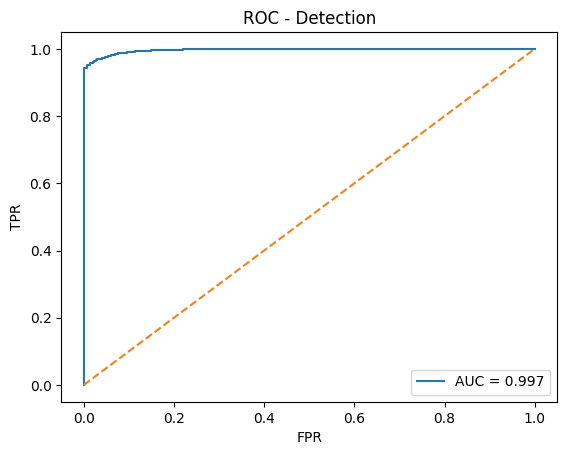

In [16]:
# ===============================
# 16. ROC Curve (Detection)
# ===============================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_det = det_model.predict_proba(X_te_det)[:,1]

fpr, tpr, _ = roc_curve(y_te_det, y_prob_det)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.3f"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC - Detection")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
import shap

# Sample for performance (SHAP can be slow on large test sets)
X_sample = X_te_det[:200]
explainer = shap.TreeExplainer(det_model)
shap_values = explainer.shap_values(X_sample)

# Visualization
plt.title("SHAP Feature Importance (Detection Model)")
shap.summary_plot(shap_values[1], X_sample, feature_names=X.columns)

In [17]:
# ===============================
# 17. Extract Anomalies
# ===============================

anom_idx = y_det == 1

X_anom = X_scaled[anom_idx]
y_anom = y_cls[anom_idx]

print("Anomaly Samples:", X_anom.shape)

Anomaly Samples: (7500, 8)


In [18]:
# ===============================
# 18. Encode Classification Labels
# ===============================

from sklearn.preprocessing import LabelEncoder

le_cls = LabelEncoder()

y_anom_enc = le_cls.fit_transform(y_anom)

print("Classes:", le_cls.classes_)

Classes: ['CPU_Saturation' 'Interrupt_Stress' 'Memory_Pressure' 'Mixed_Load'
 'True_Interrupt_Storm']


In [19]:
# ===============================
# 19. Train/Test Split (Classification)
# ===============================

X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    X_anom,
    y_anom_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_anom_enc
)

In [20]:
# ===============================
# 20. Parameter Grid (Classification)
# ===============================

param_grid_cls = {

    "n_estimators": [200, 300, 400],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt", "log2"]
}

In [21]:
# ===============================
# 21. GridSearch - Classification
# ===============================

rf_base_cls = RandomForestClassifier(random_state=42)

grid_cls = GridSearchCV(
    rf_base_cls,
    param_grid_cls,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_cls.fit(X_tr_cls, y_tr_cls)

print("Best Classification Params:")
print(grid_cls.best_params_)

clf = grid_cls.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Classification Params:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


In [22]:
print("Feature columns:")
print(X.columns)

Feature columns:
Index(['cpu', 'run_id', 'mem_before_kb', 'mem_after_kb', 'irq_before',
       'irq_after', 'softirq_before', 'softirq_after'],
      dtype='object')


In [23]:
# ===============================
# 22. Evaluate Classification
# ===============================

y_pred_cls = clf.predict(X_te_cls)

print("Tuned Classification Results:\n")
print(classification_report(
    y_te_cls,
    y_pred_cls,
    target_names=le_cls.classes_
))

Tuned Classification Results:

                      precision    recall  f1-score   support

      CPU_Saturation       0.99      1.00      1.00       300
    Interrupt_Stress       1.00      1.00      1.00       300
     Memory_Pressure       1.00      1.00      1.00       300
          Mixed_Load       1.00      0.99      1.00       300
True_Interrupt_Storm       1.00      1.00      1.00       300

            accuracy                           1.00      1500
           macro avg       1.00      1.00      1.00      1500
        weighted avg       1.00      1.00      1.00      1500



In [24]:
# ===============================
# 23. Feature Importance
# ===============================

import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": det_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_imp.head(15)

,Feature,Importance
2,mem_before_kb,0.374581
5,irq_after,0.198537
4,irq_before,0.169438
0,cpu,0.135383
3,mem_after_kb,0.089905
1,run_id,0.020820
7,softirq_after,0.008756
6,softirq_before,0.002580


In [25]:
# ===============================
# 24. Final Hybrid Prediction System (Guaranteed Fix)
# ===============================

def hybrid_system(sample_df):
    """
    sample_df : pandas DataFrame
                Must contain same feature columns as X
    """

    # Keep same column order
    sample_df = sample_df[X.columns]

    # Copy
    sample_encoded = sample_df.copy()

    #  Explicitly encode run_id
    if 'run_id' in encoders:

        sample_encoded['run_id'] = encoders['run_id'].transform(
            sample_encoded['run_id'].astype(str)
        )

    # Scale
    sample_scaled = scaler.transform(sample_encoded)

    # Stage 1: Detection
    det_pred = det_model.predict(sample_scaled)

    results = []

    for i, d in enumerate(det_pred):

        if d == 1:

            cls_pred = clf.predict(sample_scaled[i].reshape(1, -1))
            cls_label = le_cls.inverse_transform(cls_pred)[0]

            results.append(("Anomaly", cls_label))

        else:

            results.append(("Normal", "Normal"))

    return results

In [26]:
test_sample = X.iloc[[8999]]
print(hybrid_system(test_sample))

[('Anomaly', 'True_Interrupt_Storm')]


Research Metric - MCC: 0.9022


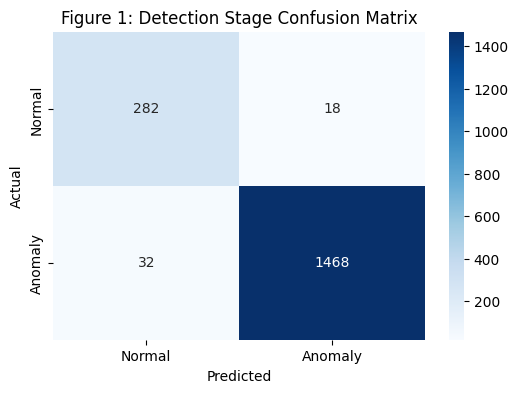

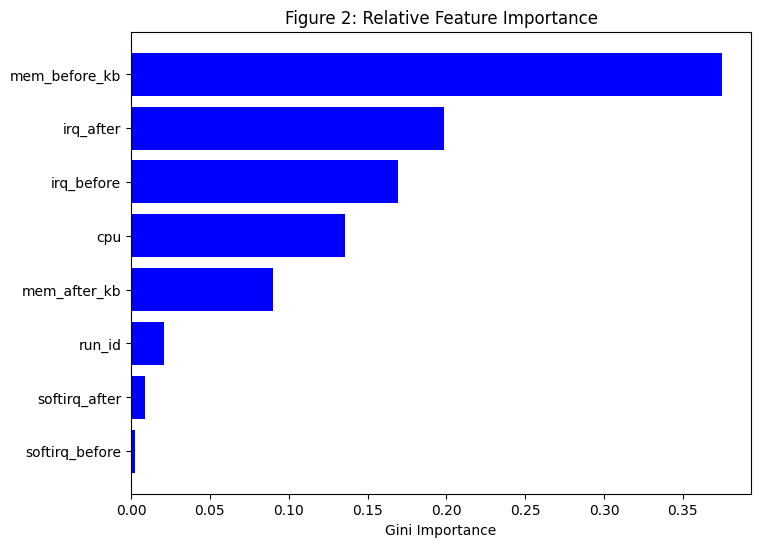

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef

# 1. Calculate Core Research Metrics
mcc = matthews_corrcoef(y_te_det, y_pred_det)
print(f"Research Metric - MCC: {mcc:.4f}")

# 2. Confusion Matrix for Detection (Binary)
cm_det = confusion_matrix(y_te_det, y_pred_det)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_det, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Figure 1: Detection Stage Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. Feature Importance Plot
importances = det_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.title('Figure 2: Relative Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Gini Importance')
plt.show()

In [30]:
from sklearn.metrics import matthews_corrcoef, confusion_matrix

# Predictions from detection model
y_pred_det = det_model.predict(X_te_det)

# MCC Score
mcc = matthews_corrcoef(y_te_det, y_pred_det)

print("Matthews Correlation Coefficient (Detection):", mcc)

Matthews Correlation Coefficient (Detection): 0.9021733347646357
